# RQ1 — How does midtown speed change over the year?

> *"Over the course of a standard year, how does the average speed of surface
> streets change?"*

Method notes that apply throughout:

- Speed is **distance-weighted** (total miles ÷ total hours), per Phase 2 item 6.
- **Weekdays only.** Weekend traffic is a different animal and its share varies
  by week, which would otherwise masquerade as seasonality.
- Weekly figures are **weekday-mix adjusted**: each day-of-week is averaged
  within the week, then across the five, so a week missing a Monday is not
  compared against one that has all five.
- **Outage days dropped** (`panel.drop_outages`).
- 2020–21 are excluded from the seasonal baseline as anomalous, but kept in the
  by-year views where the anomaly is the point.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))

import analysis as an
import panel as pnl
from constants import BAND_ORDER, TIME_BAND_LABELS

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)

panel = pnl.drop_outages(pnl.load_panel())
panel["date"] = pd.to_datetime(panel["date"])
panel["year"] = panel.date.dt.year

CLEAN_YEARS = [2022, 2023, 2024, 2025]
print(f"{len(panel):,} panel rows; clean years for the seasonal baseline: {CLEAN_YEARS}")

387,107 panel rows; clean years for the seasonal baseline: [2022, 2023, 2024, 2025]


## The shape of the year

One chart to carry the article: average weekday speed by week of year, across
the clean years.

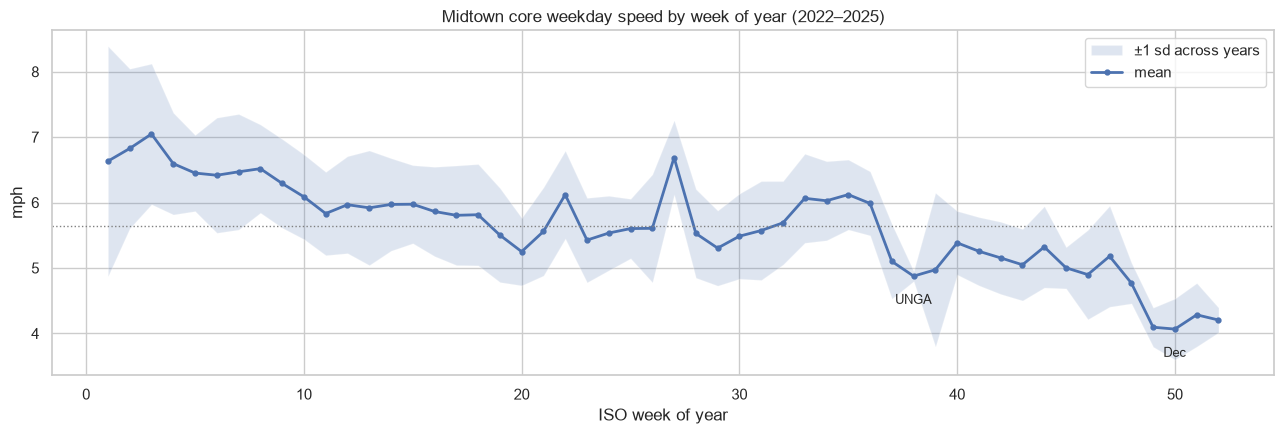

slowest weeks:
 iso_week  mph   sd  n_years
       50 4.07 0.47        4
       49 4.09 0.30        4
       52 4.21 0.19        4
       51 4.28 0.48        4
       48 4.77 0.31        4
       38 4.88 0.08        3

fastest weeks:
 iso_week  mph   sd  n_years
        3 7.05 1.07        4
        2 6.83 1.22        4
       27 6.69 0.57        4
        1 6.63 1.76        4
        4 6.59 0.78        4
        8 6.52 0.67        4


In [2]:
profile = an.seasonal_profile(panel, years=CLEAN_YEARS)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.fill_between(profile.iso_week, profile.mph - profile.sd, profile.mph + profile.sd,
                alpha=0.18, label="±1 sd across years")
ax.plot(profile.iso_week, profile.mph, lw=2, marker="o", ms=3.5, label="mean")
ax.axhline(profile.mph.mean(), color="grey", ls=":", lw=1)

for wk, txt in [(38, "UNGA"), (50, "Dec")]:
    ax.annotate(txt, (wk, profile.set_index("iso_week").mph.loc[wk]),
                textcoords="offset points", xytext=(0, -20), ha="center", fontsize=9)

ax.set(xlabel="ISO week of year", ylabel="mph",
       title=f"Midtown core weekday speed by week of year ({CLEAN_YEARS[0]}–{CLEAN_YEARS[-1]})")
ax.legend()
plt.tight_layout(); plt.show()

print("slowest weeks:"); print(profile.nsmallest(6, "mph").round(2).to_string(index=False))
print("\nfastest weeks:"); print(profile.nlargest(6, "mph").round(2).to_string(index=False))

## By month — the same story, more quotable

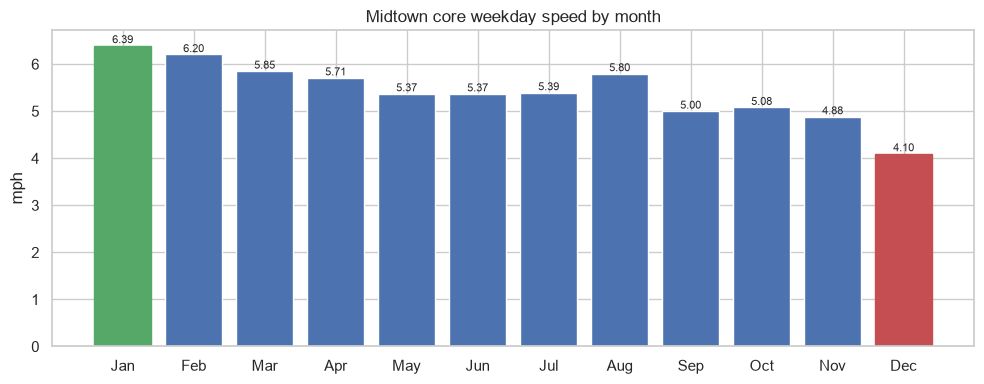

,month,name,mph,trips
0,1,Jan,6.39,304085
1,2,Feb,6.20,312001
2,3,Mar,5.85,380536
3,4,Apr,5.71,353384
4,5,May,5.37,369478
5,6,Jun,5.37,362610
6,7,Jul,5.39,360079
7,8,Aug,5.80,333604
8,9,Sep,5.00,316569
9,10,Oct,5.08,364644


In [3]:
d = an.daily(panel, area="midtown_core", weekdays_only=True)
d["month"] = d.date.dt.month
monthly = an.agg(d[d.date.dt.year.isin(CLEAN_YEARS)], ["month"])
monthly["name"] = pd.to_datetime(monthly.month, format="%m").dt.strftime("%b")

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(monthly.name, monthly.mph, color="#4C72B0")
bars[monthly.mph.idxmin()].set_color("#C44E52")
bars[monthly.mph.idxmax()].set_color("#55A868")
ax.set(ylabel="mph", title="Midtown core weekday speed by month")
for b, v in zip(bars, monthly.mph):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.2f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

monthly[["month", "name", "mph", "trips"]].round(2)

## Is the seasonal swing stable, or is it the trend?

Midtown got slower every year (Phase 2). Separating "the year got worse" from
"this week of the year is always bad" means indexing each week to its own
year's median.

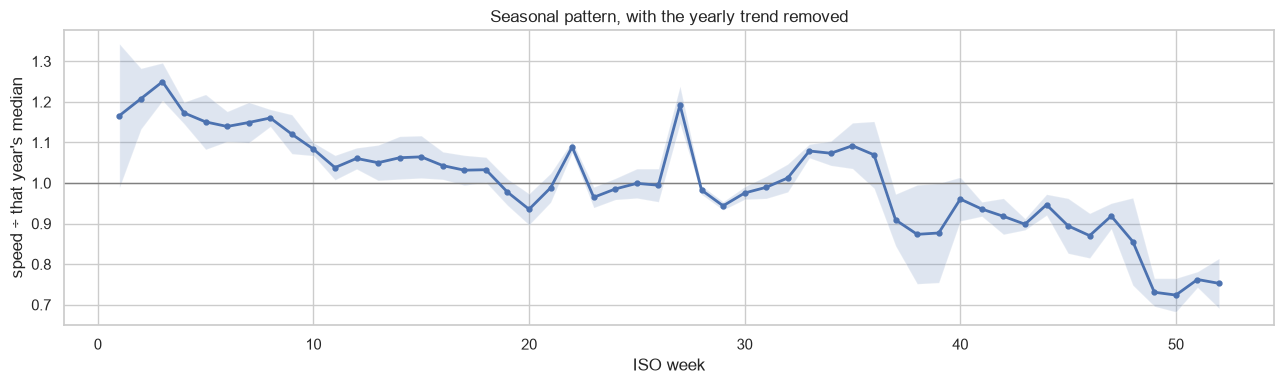

weeks furthest below their year's median:
 iso_week  mean   std  size
       50 0.724 0.041     4
       49 0.731 0.034     4
       52 0.753 0.061     4
       51 0.762 0.019     4
       48 0.856 0.108     4
       46 0.870 0.055     4


In [4]:
weekly = an.weekday_mix_adjusted(panel)
weekly = weekly[weekly.dows >= 4]
med = weekly.groupby("iso_year").mph.transform("median")
weekly["rel"] = weekly.mph / med

rel = (weekly[weekly.iso_year.isin(CLEAN_YEARS)]
       .groupby("iso_week").rel.agg(["mean", "std", "size"]).reset_index())

fig, ax = plt.subplots(figsize=(13, 4))
ax.axhline(1.0, color="grey", lw=1)
ax.fill_between(rel.iso_week, rel["mean"]-rel["std"], rel["mean"]+rel["std"], alpha=0.18)
ax.plot(rel.iso_week, rel["mean"], lw=2, marker="o", ms=3.5)
ax.set(xlabel="ISO week", ylabel="speed ÷ that year's median",
       title="Seasonal pattern, with the yearly trend removed")
plt.tight_layout(); plt.show()

print("weeks furthest below their year's median:")
print(rel.nsmallest(6, "mean").round(3).to_string(index=False))

## Time of day across the year

Phase 2 found the 2019→2026 decline was far from uniform across the day. Does
the *seasonal* pattern differ by band too?

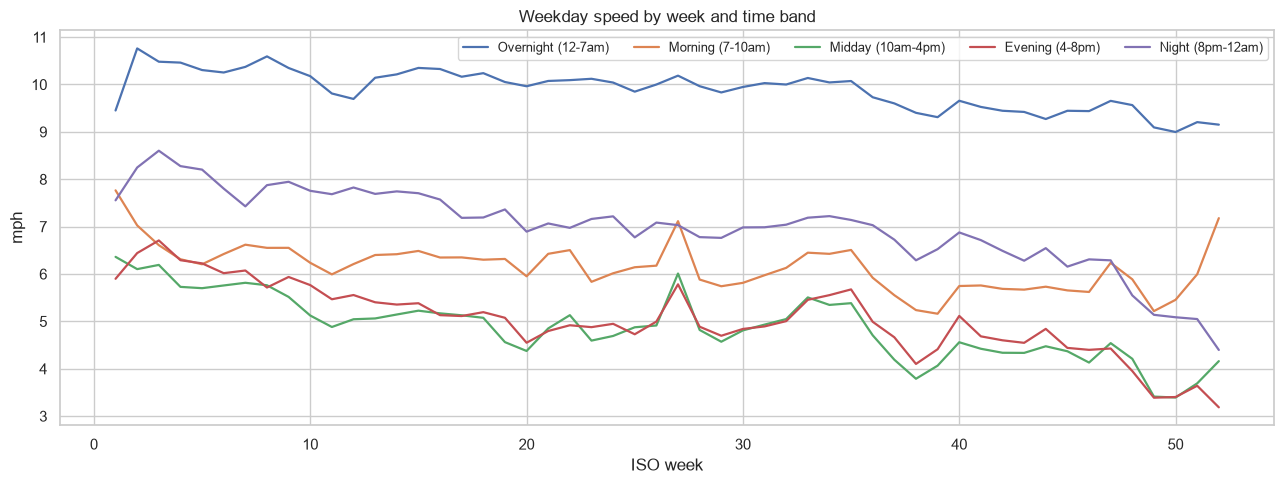

,min,max,mean,swing_pct
Overnight (12-7am),9.00,10.76,9.89,17.8
Morning (7-10am),5.16,7.77,6.15,42.3
Midday (10am-4pm),3.39,6.36,4.88,60.8
Evening (4-8pm),3.19,6.71,5.04,69.9
Night (8pm-12am),4.40,8.60,6.99,60.2


In [5]:
bw = an.band_by_week(panel, years=CLEAN_YEARS)

fig, ax = plt.subplots(figsize=(13, 5))
for band in BAND_ORDER:
    s = bw[bw.band == band]
    ax.plot(s.iso_week, s.mph, lw=1.6, label=TIME_BAND_LABELS[band])
ax.set(xlabel="ISO week", ylabel="mph", title="Weekday speed by week and time band")
ax.legend(ncol=5, fontsize=9)
plt.tight_layout(); plt.show()

# Relative swing within each band: how much seasonality does each one carry?
swing = bw.groupby("band", observed=True).mph.agg(["min", "max", "mean"])
swing["swing_pct"] = ((swing["max"] - swing["min"]) / swing["mean"] * 100).round(1)
swing.index = [TIME_BAND_LABELS[i] for i in swing.index]
swing.round(2)

## The yearly trend, by band

The finding from Phase 2 that deserves its own section in the article.

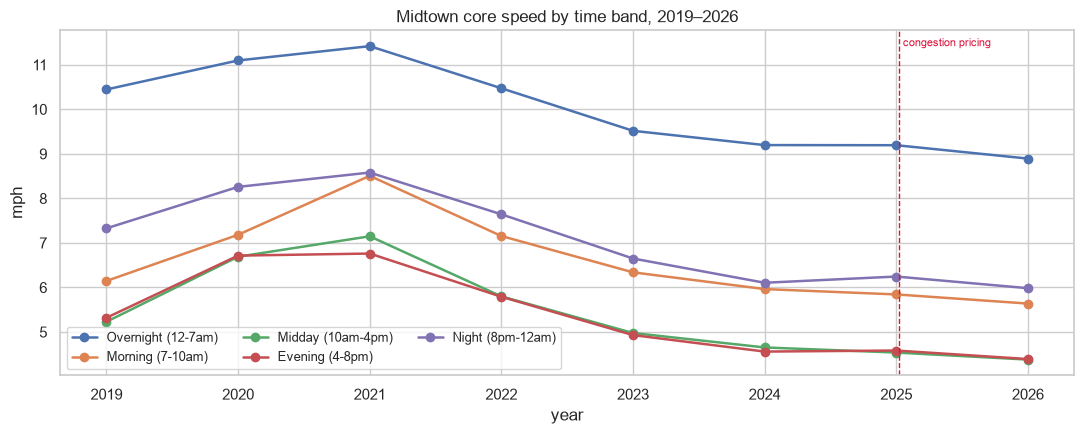

,2019,2026,change,pct
Overnight (12-7am),10.45,8.89,-1.55,-14.86
Morning (7-10am),6.15,5.64,-0.51,-8.26
Midday (10am-4pm),5.23,4.38,-0.85,-16.24
Evening (4-8pm),5.32,4.39,-0.93,-17.43
Night (8pm-12am),7.33,5.98,-1.34,-18.34


In [6]:
by = pnl.by_band(panel, extra_keys=["year"], area="midtown_core")
piv = by.pivot(index="year", columns="band", values="mph")[BAND_ORDER]

fig, ax = plt.subplots(figsize=(11, 4.5))
for band in BAND_ORDER:
    ax.plot(piv.index, piv[band], marker="o", lw=1.8, label=TIME_BAND_LABELS[band])
ax.axvline(2025.02, color="crimson", ls="--", lw=1)
ax.text(2025.05, ax.get_ylim()[1]*0.97, "congestion pricing", fontsize=8, color="crimson")
ax.set(xlabel="year", ylabel="mph", title="Midtown core speed by time band, 2019–2026")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

change = pd.DataFrame({
    "2019": piv.loc[2019], "2026": piv.loc[2026],
    "change": (piv.loc[2026] - piv.loc[2019]),
    "pct": ((piv.loc[2026] / piv.loc[2019] - 1) * 100),
})
change.index = [TIME_BAND_LABELS[i] for i in change.index]
change.round(2)

## Does weather explain the seasonal shape?

Winter is both slow and wet. Check whether the December collapse survives
dropping wet hours entirely.

In [7]:
dry = panel[~panel.is_wet.fillna(False)]
both = []
for label, frame in [("all weather", panel), ("dry hours only", dry)]:
    d = an.daily(frame, area="midtown_core", weekdays_only=True)
    d["month"] = d.date.dt.month
    m = an.agg(d[d.date.dt.year.isin(CLEAN_YEARS)], ["month"]).set_index("month").mph
    both.append(m.rename(label))

cmp = pd.concat(both, axis=1)
cmp["difference"] = (cmp["dry hours only"] - cmp["all weather"]).round(3)
print(cmp.round(2).to_string())
print("\nDecember vs January gap:")
for c in ["all weather", "dry hours only"]:
    print(f"  {c:16s} {cmp.loc[1, c]:.2f} → {cmp.loc[12, c]:.2f}  "
          f"({(cmp.loc[12, c]/cmp.loc[1, c]-1)*100:+.1f}%)")

       all weather  dry hours only  difference
month                                         
1             6.39            6.46        0.06
2             6.20            6.18       -0.02
3             5.85            5.91        0.06
4             5.71            5.78        0.07
5             5.37            5.54        0.17
6             5.37            5.38        0.02
7             5.39            5.52        0.13
8             5.80            5.90        0.11
9             5.00            5.08        0.08
10            5.08            5.06       -0.02
11            4.88            4.93        0.05
12            4.10            4.13        0.03

December vs January gap:
  all weather      6.39 → 4.10  (-35.9%)
  dry hours only   6.46 → 4.13  (-36.0%)


---

## Findings

Recorded in `research/rq1_seasonality.md`.